<a href="https://colab.research.google.com/github/sahdahx/PDS/blob/main/PDS_T2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tugas 2: Introduction to Data Science - Pengantar Data Sains**
**Analisis Statistik Dataset Gaming and Mental Health**

> Nama: Sahda Huwaidah Estiningtyas

> NIM: 24/545080/PA/23156

> email: sahdahuwaidahestiningtyas@mail.ugm.ac.id

# **Assignment - Week 3**

## 1) Dataset Publik dari Kaggle

### Deskripsi dataset
Dataset yang digunakan adalah **Gaming and Mental Health** yang diperoleh dari [Kaggle](https://drive.google.com/file/d/1SN6BBUyObFYbNlSkQ3NvGk55-Xh0mywb/view). Dataset ini berisi informasi mengenai perilaku bermain game serta dampaknya terhadap pola tidur dan gaya hidup.

Setiap baris merepresentasikan 1 individu (gamer) dengan karakteristik demografis, durasi bermain game, genre dan platform game yang digunakan, kualitas tidur, serta indikator risiko kecanduan.

### Jumlah observasi
Dataset terdiri dari **1.000 observasi dengan 27 variabel**.

### Cakupan variabel
- Identitas & Demografi: `record_id`, `age`, `gender`
- Perilaku Gaming: `daily_gaming_hours`, `game_genre`, `primary_game`, `gaming_platform`, `years_gaming`, `monthly_game_spending_usd`
- Tidur & Kesehatan: `sleep_hours`, `sleep_quality`, `sleep_disruption_frequency`, `eye_strain`, `back_neck_pain`
- Akademik & Produktivitas: `academic_work_performance`, `grades_gpa`, `work_productivity_score`
- Kondisi Psikologis & Emosional: `mood_state`, `mood_swing_frequency`, `withdrawal_symptoms`, `loss_of_other_interests`, `continued_despite_problems`
- Gaya Hidup & Sosial: `exercise_hours_weekly`, `social_isolation_score`, `face_to_face_social_hours_weekly`
- Risiko Kecanduan: `gaming_addiction_risk_level`

Sumber dataset:
[Gaming and Mental Health – Kaggle](https://drive.google.com/file/d/1SN6BBUyObFYbNlSkQ3NvGk55-Xh0mywb/view)

## 2) Load Data ke DataFrame df

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Gaming and Mental Health.csv")
df

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,GD0996,15,Female,8.6,Strategy,Age of Empires,PC,4.1,Very Poor,Always,...,True,True,True,1.9,7.5,6,2.4,426.54,3,Severe
996,GD0997,18,Male,5.4,MMO,Elder Scrolls Online,Multi-platform,6.5,Fair,Never,...,False,True,False,2.1,7.7,1,10.9,83.71,7,Low
997,GD0998,23,Male,7.3,RPG,Skyrim,PC,3.9,Insomnia,Rarely,...,False,False,True,0.5,8.1,5,6.7,88.60,5,High
998,GD0999,18,Male,3.1,Strategy,StarCraft II,Console,8.2,Fair,Sometimes,...,False,False,False,0.8,8.4,1,12.7,22.02,8,Low


In [ ]:
df.isnull().sum()

,0
record_id,0
age,0
gender,0
daily_gaming_hours,0
game_genre,0
primary_game,0
gaming_platform,0
sleep_hours,0
sleep_quality,0
sleep_disruption_frequency,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        754 non-null    float64
 12  work_pr

## 3) Rapikan Data

### a) Pastikan tiap baris = 1 observasi
Dari deskripsi dataset, setiap baris sudah merepresentasikan 1 individu sehingga sudah sesuai.

### b) Drop kolom yang tidak diperlukan
Variabel `record_id` tidak dibutuhkan untuk analisis numerik/kategorik sehingga perlu didrop.

In [ ]:
# Drop kolom
df_clean = df.drop(columns=['record_id'])

## 4) Periksa Missing Values

**Interpretasi:**

Variabel `grades_gpa` memiliki 246 missing value (24,6%) dan `work_productivity_score` memiliki 326 missing value (32,6%). Karena persentase missing value ≥ 5%, maka tidak disarankan untuk langsung menghapus baris tersebut karena dapat mengurangi jumlah observasi secara signifikan dan berpotensi menimbulkan bias.

Pengisian missing value dapat menggunakan mean atau median.
- Mean digunakan jika distribusi data normal dan tidak memiliki outlier ekstrem.
- Median digunakan jika data cenderung skewed atau memiliki outlier karena median lebih robust (tidak terpengaruh nilai ekstrem).

Pada analisis ini, missing value diisi menggunakan median karena nilai GPA dan skor produktivitas berpotensi memiliki distribusi tidak simetris (skewness) dan kemungkinan terdapat nilai ekstrem (outlier). Median dipilih agar representasi nilai tengah lebih stabil dan tidak bias terhadap outlier.

In [ ]:
# Cek missing value per kolom
df_clean.isnull().sum()

,0
age,0
gender,0
daily_gaming_hours,0
game_genre,0
primary_game,0
gaming_platform,0
sleep_hours,0
sleep_quality,0
sleep_disruption_frequency,0
academic_work_performance,0


In [ ]:
# Isi missing value dengan median
df_clean['grades_gpa'] = df_clean['grades_gpa'].fillna(df_clean['grades_gpa'].median())
df_clean['work_productivity_score'] = df_clean['work_productivity_score'].fillna(df_clean['work_productivity_score'].median())

# Cek kembali missing value
df_clean.isnull().sum()

,0
age,0
gender,0
daily_gaming_hours,0
game_genre,0
primary_game,0
gaming_platform,0
sleep_hours,0
sleep_quality,0
sleep_disruption_frequency,0
academic_work_performance,0


## 5) Manipulasi Data – Buat Variabel Baru

**Interpretasi:**

1. Variabel `gaming_to_sleep_ratio` dibuat dengan membagi `daily_gaming_hours` dengan `sleep_hours`. Rasio ini digunakan untuk melihat keseimbangan antara waktu bermain game dan waktu tidur. Jika nilai rasio > 1, artinya waktu bermain game lebih lama daripada waktu tidur dalam sehari. Semakin tinggi nilai rasio, semakin besar potensi ketidakseimbangan gaya hidup yang dapat berdampak pada kesehatan.

   Perhitungan menggunakan pembagian langsung karena tujuan analisis adalah membandingkan proporsi dua aktivitas harian utama (gaming vs tidur) dalam skala yang sama (jam per hari).

2. Variabel `heavy_gamer` dibuat sebagai variabel biner (0 dan 1) berdasarkan batas > 5 jam per hari. Angka 5 jam dipilih sebagai threshold untuk mengidentifikasi individu dengan durasi bermain yang relatif tinggi dalam konteks aktivitas harian.

   **Nilai 1 menunjukkan heavy gamer** (lebih dari 5 jam per hari), sedangkan **0 menunjukkan non-heavy gamer**. Variabel ini memudahkan analisis kategorikal, seperti grouping, pivot table, atau perbandingan rata-rata antar kelompok.

In [ ]:
# Membuat variabel Rasio Gaming vs Tidur
df_clean['gaming_to_sleep_ratio'] = df_clean['daily_gaming_hours'] / df_clean['sleep_hours']

# Membuat variabel Heavy Gamer (binary)
df_clean['heavy_gamer'] = df_clean['daily_gaming_hours'].apply(lambda x: 1 if x > 6 else 0)

In [ ]:
df_clean['gaming_to_sleep_ratio']

,gaming_to_sleep_ratio
0,3.000000
1,0.416667
2,1.727273
3,1.411765
4,2.000000
...,...
995,2.097561
996,0.830769
997,1.871795
998,0.378049


In [ ]:
df_clean['heavy_gamer']

,heavy_gamer
0,1
1,0
2,1
3,1
4,1
...,...
995,1
996,0
997,1
998,0


## 6) Sorting

**Interpretasi:**

1. **Sorting berdasarkan `daily_gaming_hours`**

   Data diurutkan berdasarkan variabel `daily_gaming_hours` secara menurun (*descending*) untuk mengidentifikasi individu dengan durasi bermain game tertinggi. Proses ini bertujuan untuk menampilkan 10 gamer dengan jam bermain paling tinggi.

   Hasil sorting menunjukkan bahwa durasi bermain tertinggi mencapai **15.1 jam per hari**, dengan sebagian besar individu pada kelompok ini memiliki **waktu tidur yang cukup rendah (sekitar 3–5 jam)** serta banyak yang berada pada kategori risiko kecanduan High hingga Severe. Hal ini menunjukkan bahwa intensitas bermain yang sangat tinggi berpotensi berkaitan dengan penurunan waktu tidur dan peningkatan risiko kecanduan.


2. **Sorting berdasarkan `monthly_game_spending_usd`**
   
   Data diurutkan berdasarkan variabel `monthly_game_spending_usd` secara menurun (*descending*) untuk melihat 10 gamer dengan pengeluaran bulanan tertinggi untuk game. Sorting ini membantu mengidentifikasi pola konsumsi finansial dalam aktivitas gaming.

   Hasil menunjukkan bahwa pengeluaran tertinggi mendekati **USD 500 per bulan**. Individu dengan pengeluaran besar umumnya juga memiliki **durasi bermain yang cukup tinggi (sekitar 8–13 jam per hari)** dan sebagian besar berada pada kategori High atau Severe addiction risk. Hal ini menginterpretasikan kecenderungan bahwa gamer yang lebih intens bermain juga cenderung mengeluarkan biaya yang lebih besar untuk aktivitas gaming.

In [ ]:
# Sorting berdasarkan daily_gaming_hours (tertinggi)
top10_gamers = df_clean.sort_values(by='daily_gaming_hours', ascending=False).head(10)
top10_gamers[['age','gender','daily_gaming_hours','sleep_hours','gaming_addiction_risk_level']]

,age,gender,daily_gaming_hours,sleep_hours,gaming_addiction_risk_level
69,18,Female,15.1,4.8,High
258,15,Male,15.1,5.7,Moderate
895,30,Male,14.7,4.2,Severe
865,19,Male,14.7,3.5,High
257,27,Male,14.2,3.4,Moderate
491,24,Male,14.1,3.9,Severe
394,26,Female,13.9,4.5,Severe
981,22,Female,13.6,5.8,Severe
741,22,Male,13.5,4.3,High
657,24,Male,13.4,3.9,High


In [ ]:
# Sorting berdasarkan monthly_game_spending_usd (tertinggi)
top10_monthly_game_spending = df_clean.sort_values(by='monthly_game_spending_usd', ascending=False).head(10)
top10_monthly_game_spending[['age','gender','daily_gaming_hours', 'monthly_game_spending_usd','sleep_hours','gaming_addiction_risk_level']]

,age,gender,daily_gaming_hours,monthly_game_spending_usd,sleep_hours,gaming_addiction_risk_level
90,20,Male,10.3,499.27,5.8,Moderate
367,14,Female,9.4,497.21,4.0,Severe
448,21,Male,9.1,493.27,5.3,Severe
844,19,Male,10.9,486.86,5.7,Severe
792,18,Female,8.7,486.60,6.0,Severe
216,20,Male,11.3,485.60,5.9,High
183,19,Male,11.0,484.09,3.7,High
12,28,Male,9.5,482.71,3.6,High
522,21,Female,9.1,479.29,4.7,High
606,15,Male,13.2,475.36,4.2,High


## 7) Grouping

**Interpretasi:**

1. **Grouping berdasarkan `gender`**

   Data dikelompokkan berdasarkan variabel kategorik `gender` untuk menghitung **rata-rata (mean) durasi bermain game (`daily_gaming_hours`) dan waktu tidur (`sleep_hours`)** pada masing-masing kelompok gender.

   Hasil perhitungan menunjukkan bahwa rata-rata durasi bermain pada kelompok **Male adalah sekitar 6.23 jam per hari**, sedikit lebih tinggi dibandingkan kelompok **Female yang sekitar 5.97 jam per hari**. Sementara itu, kelompok **Other memiliki rata-rata tertinggi yaitu sekitar 6.63 jam per hari**. Hal ini menunjukkan bahwa perbedaan durasi bermain antar gender tidak terlalu besar, meskipun terdapat kecenderungan bahwa laki-laki bermain sedikit lebih lama.


2. **Grouping berdasarkan `age`**

   Data juga dikelompokkan berdasarkan variabel `age` untuk menghitung **rata-rata durasi bermain game dan waktu tidur pada setiap kelompok umur**. Tujuannya adalah untuk melihat pola perilaku gaming pada berbagai kelompok usia.

   Terlihat bahwa beberapa kelompok usia memiliki durasi bermain yang relatif tinggi, misalnya **usia 15 tahun sekitar 7.26 jam per hari**, **usia 28 tahun sekitar 7.22 jam**, dan **usia 30 tahun sekitar 7.26 jam**. Sebaliknya, kelompok usia yang lebih tua seperti **34–35 tahun** memiliki rata-rata durasi bermain yang lebih rendah, yaitu sekitar **2.7 hingga 4.4 jam per hari**, tetapi dengan waktu tidur yang relatif lebih tinggi. Pola ini menunjukkan bahwa intensitas bermain game cenderung lebih tinggi pada usia remaja hingga dewasa muda.


In [ ]:
# Rata-rata jam bermain dan jam tidur berdasarkan gender
group_gender = df_clean.groupby('gender')[['daily_gaming_hours', 'sleep_hours']].mean().reset_index()
group_gender

,gender,daily_gaming_hours,sleep_hours
0,Female,5.968580,5.759215
1,Male,6.228594,5.720866
2,Other,6.631818,5.927273


In [ ]:
# Rata-rata jam bermain dan jam tidur berdasarkan umur
group_age = df_clean.groupby('age')[['daily_gaming_hours', 'sleep_hours']].mean().reset_index()
group_age

,age,daily_gaming_hours,sleep_hours
0,13,6.122222,5.833333
1,14,5.803448,5.937931
2,15,7.256098,5.280488
3,16,5.873913,5.742029
4,17,6.114286,5.751190
5,18,5.900000,5.858511
6,19,6.170000,5.607143
7,20,6.162791,5.838760
8,21,6.267470,5.815663
9,22,6.143421,5.713158


## 8) Pivot Table

**Interpretasi:**

Pivot table bertujuan untuk melihat rata-rata durasi bermain game (`daily_gaming_hours`) berdasarkan kombinasi variabel `gender` dan `gaming_addiction_risk_level`. Pada tabel ini, variabel `gender` digunakan sebagai **index**, variabel `gaming_addiction_risk_level` sebagai **columns**, dan nilai yang dihitung adalah rata-rata (`mean`) dari `daily_gaming_hours`.

Hasil pivot table menunjukkan pola yang konsisten bahwa rata-rata durasi bermain meningkat seiring dengan meningkatnya tingkat risiko kecanduan.

- Pada kategori **Low**, rata-rata durasi bermain berada di sekitar **4 jam per hari**.
- Pada kategori **Moderate**, rata-rata durasi meningkat menjadi sekitar **6–7 jam per hari**.
- Pada kategori **High**, durasi bermain berada di kisaran **8–9 jam per hari**.
- Pada kategori **Severe** durasi mencapai sekitar **9–10 jam per hari**.

Pola ini terlihat pada hampir semua kelompok gender. Temuan ini menunjukkan bahwa **tingkat risiko kecanduan memiliki hubungan yang cukup kuat dengan durasi bermain game harian**, di mana semakin tinggi tingkat risiko kecanduan, semakin besar pula rata-rata waktu yang dihabiskan untuk bermain game.

In [ ]:
pivot_table_gender = pd.pivot_table(
    df_clean,
    index='gender',
    columns='gaming_addiction_risk_level',
    values='daily_gaming_hours',
    aggfunc='mean'
)
pivot_table_gender

gaming_addiction_risk_level,High,Low,Moderate,Severe
gender,,,,
Female,8.573810,4.079545,6.692647,9.831111
Male,8.696296,3.971254,7.170940,10.032632
Other,10.075000,4.536364,7.340000,9.500000


## 9) Plotting

**Interpretasi:**

1. **Bar Plot: Rata-rata GPA berdasarkan `gaming_addiction_risk_level`**

   Bar plot digunakan untuk membandingkan rata-rata GPA (`grades_gpa`) pada setiap tingkat risiko kecanduan game.

   Hasil visualisasi menunjukkan bahwa kelompok dengan **risiko kecanduan lebih tinggi cenderung memiliki rata-rata GPA yang lebih rendah**. Pola ini menunjukkan bahwa intensitas kecanduan gaming berpotensi berkaitan dengan penurunan performa akademik.

2. **Scatter Plot: `daily_gaming_hours` vs `grades_gpa`**

   Scatter plot digunakan untuk melihat hubungan antara durasi bermain game per hari (`daily_gaming_hours`) dan performa akademik (`grades_gpa`). Setiap titik merepresentasikan satu individu dengan warna yang menunjukkan kategori `gaming_addiction_risk_level`.

   Berdasarkan visualisasi, titik-titik data **tersebar acak tanpa pola linear yang jelas** antara jam bermain game dan GPA. Hal ini menunjukkan bahwa hubungan langsung antara durasi bermain game dan nilai GPA tidak terlalu kuat.

   Meskipun demikian, terlihat bahwa individu dengan kategori **High dan Severe addiction risk** cenderung muncul pada **rentang jam bermain yang lebih tinggi (sekitar 6–12 jam per hari)**. Ini menunjukkan bahwa tingkat risiko kecanduan lebih berkaitan dengan intensitas bermain game, meskipun dampaknya terhadap GPA tidak selalu konsisten pada semua individu.


**Kesimpulan Visual:**
* Individu dengan risiko kecanduan lebih tinggi umumnya memiliki durasi bermain game yang lebih besar.
* Visualisasi scatter plot menunjukkan adanya kecenderungan hubungan antara jam bermain game dan performa akademik, di mana durasi bermain yang lebih tinggi sering muncul pada individu dengan GPA yang lebih rendah atau lebih bervariasi.

/tmp/ipykernel_280/1410908767.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


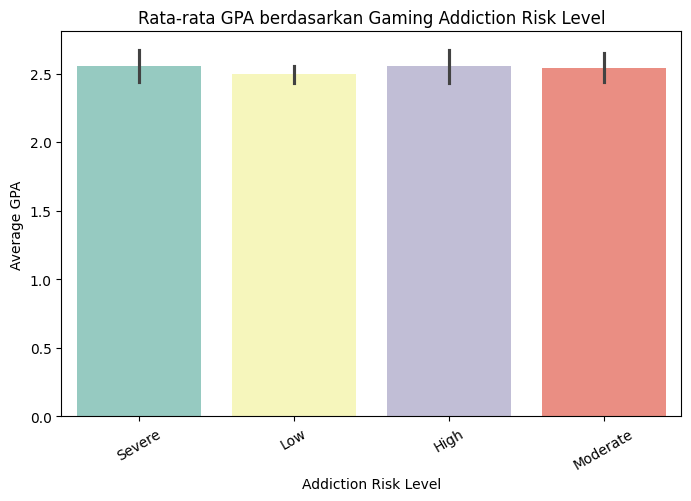

In [ ]:
# Bar Plot: Rata-rata GPA berdasarkan Addiction Risk Level
plt.figure(figsize=(8,5))
sns.barplot(
    data=df_clean,
    x='gaming_addiction_risk_level',
    y='grades_gpa',
    palette='Set3'
)

plt.title('Rata-rata GPA berdasarkan Gaming Addiction Risk Level')
plt.xlabel('Addiction Risk Level')
plt.ylabel('Average GPA')
plt.xticks(rotation=30)
plt.show()

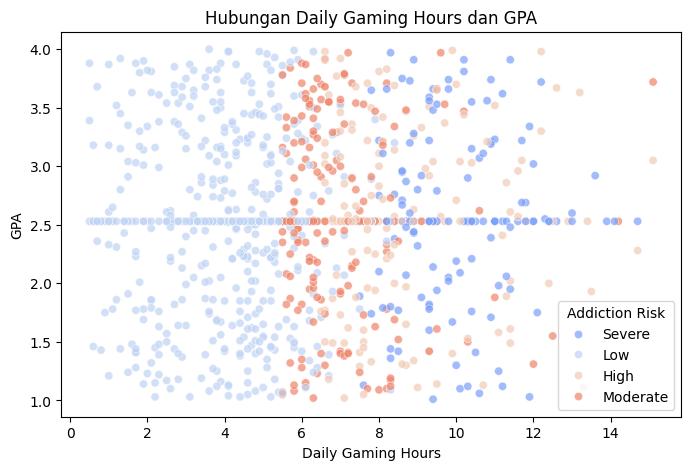

In [ ]:
# Scatter Plot: Gaming Hours vs GPA
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_clean,
    x='daily_gaming_hours',
    y='grades_gpa',
    hue='gaming_addiction_risk_level',
    palette='coolwarm',
    alpha=0.7
)

plt.title('Hubungan Daily Gaming Hours dan GPA')
plt.xlabel('Daily Gaming Hours')
plt.ylabel('GPA')
plt.legend(title='Addiction Risk')
plt.show()

## 10) Penjelasan singkat

- **Observation (Unit Analisis)**  
   Unit analisis dalam dataset ini adalah **individu gamer**, di mana setiap baris merepresentasikan satu orang dengan karakteristik demografi, perilaku gaming, kesehatan, serta performa akademik.

- **Variabel**  
   Dataset memiliki 27 variabel, yang mencakup:
   - Identitas & Demografi: `record_id`, `age`, `gender`
   - Perilaku Gaming: `daily_gaming_hours`, `game_genre`, `primary_game`, `gaming_platform`, `years_gaming`, `monthly_game_spending_usd`
   - Tidur & Kesehatan: `sleep_hours`, `sleep_quality`, `sleep_disruption_frequency`, `eye_strain`, `back_neck_pain`
   - Akademik & Produktivitas: `academic_work_performance`, `grades_gpa`, `work_productivity_score`
   - Kondisi Psikologis & Emosional: `mood_state`, `mood_swing_frequency`, `withdrawal_symptoms`, `loss_of_other_interests`, `continued_despite_problems`
   - Gaya Hidup & Sosial: `exercise_hours_weekly`, `social_isolation_score`, `face_to_face_social_hours_weekly`
   - Risiko Kecanduan: `gaming_addiction_risk_level`

- **Skala Pengukuran**
  - **Nominal:** `record_id`, `gender`, `game_genre`, `primary_game`, `gaming_platform`, `mood_state`
  - **Ordinal:** `sleep_quality`, `sleep_disruption_frequency`, `mood_swing_frequency`, `academic_work_performance`, `gaming_addiction_risk_level`
  - **Interval:** `grades_gpa`, `work_productivity_score`
  - **Ratio:** `age`, `daily_gaming_hours`, `sleep_hours`, `monthly_game_spending_usd`, `years_gaming`, `exercise_hours_weekly`, `face_to_face_social_hours_weekly`, `weight_change_kg`, `social_isolation_score`

In [ ]:
import numpy as np
import pandas as pd

# data penjualan
penjualan = [120,135,128,140,150,145,155,160,158,165,
             170,168,175,180,178,185,190,195,200,205]

bulan = np.arange(1,21)

data = pd.DataFrame({
    "Bulan": bulan,
    "Penjualan": penjualan
})

data

,Bulan,Penjualan
0,1,120
1,2,135
2,3,128
3,4,140
4,5,150
5,6,145
6,7,155
7,8,160
8,9,158
9,10,165


In [ ]:
# Naive Forecast
data["Naive"] = data["Penjualan"].shift(1)

data

,Bulan,Penjualan,Naive
0,1,120,NaN
1,2,135,120.0
2,3,128,135.0
3,4,140,128.0
4,5,150,140.0
5,6,145,150.0
6,7,155,145.0
7,8,160,155.0
8,9,158,160.0
9,10,165,158.0


In [ ]:
naive_21 = penjualan[-1]
print("Ramalan bulan 21 (Naive):", naive_21)

Ramalan bulan 21 (Naive): 205


In [ ]:
ma3_21 = np.mean(penjualan[-3:])
print("Ramalan bulan 21 (MA3):", ma3_21)

Ramalan bulan 21 (MA3): 200.0


In [ ]:
# Moving Average orde 3
data["MA3"] = data["Penjualan"].rolling(window=3).mean().shift(1)

data

,Bulan,Penjualan,Naive,MA3
0,1,120,NaN,NaN
1,2,135,120.0,NaN
2,3,128,135.0,NaN
3,4,140,128.0,127.666667
4,5,150,140.0,134.333333
5,6,145,150.0,139.333333
6,7,155,145.0,145.000000
7,8,160,155.0,150.000000
8,9,158,160.0,153.333333
9,10,165,158.0,157.666667


In [ ]:
alpha = 0.3

# list forecast
forecast = [penjualan[0]]  # F1 = Y1

for t in range(1, len(penjualan)):
    ft = alpha * penjualan[t-1] + (1-alpha) * forecast[t-1]
    forecast.append(ft)

data["SES"] = forecast

data

,Bulan,Penjualan,Naive,MA3,SES
0,1,120,NaN,NaN,120.000000
1,2,135,120.0,NaN,120.000000
2,3,128,135.0,NaN,124.500000
3,4,140,128.0,127.666667,125.550000
4,5,150,140.0,134.333333,129.885000
5,6,145,150.0,139.333333,135.919500
6,7,155,145.0,145.000000,138.643650
7,8,160,155.0,150.000000,143.550555
8,9,158,160.0,153.333333,148.485388
9,10,165,158.0,157.666667,151.339772


In [ ]:
f21 = alpha * penjualan[-1] + (1-alpha) * forecast[-1]
print("Ramalan bulan 21 (SES):", f21)

Ramalan bulan 21 (SES): 194.04736267711255


In [ ]:
# error kuadrat
data["Error_Naive"] = (data["Penjualan"] - data["Naive"])**2
data["Error_MA3"] = (data["Penjualan"] - data["MA3"])**2
data["Error_SES"] = (data["Penjualan"] - data["SES"])**2

data

,Bulan,Penjualan,Naive,MA3,SES,Error_Naive,Error_MA3,Error_SES
0,1,120,NaN,NaN,120.000000,NaN,NaN,0.000000
1,2,135,120.0,NaN,120.000000,225.0,NaN,225.000000
2,3,128,135.0,NaN,124.500000,49.0,NaN,12.250000
3,4,140,128.0,127.666667,125.550000,144.0,152.111111,208.802500
4,5,150,140.0,134.333333,129.885000,100.0,245.444444,404.613225
5,6,145,150.0,139.333333,135.919500,25.0,32.111111,82.455480
6,7,155,145.0,145.000000,138.643650,100.0,100.000000,267.530185
7,8,160,155.0,150.000000,143.550555,25.0,100.000000,270.584241
8,9,158,160.0,153.333333,148.485388,4.0,21.777778,90.527832
9,10,165,158.0,157.666667,151.339772,49.0,53.777778,186.601830


In [ ]:
mse_naive = data["Error_Naive"].mean()
mse_ma3 = data["Error_MA3"].mean()
mse_ses = data["Error_SES"].mean()

print("MSE Naive:", mse_naive)
print("MSE MA3:", mse_ma3)
print("MSE SES:", mse_ses)

MSE Naive: 51.421052631578945
MSE MA3: 82.14379084967317
MSE SES: 173.69269443016134


In [ ]:
mse = {
    "Naive": mse_naive,
    "MA3": mse_ma3,
    "SES": mse_ses
}

metode_terbaik = min(mse, key=mse.get)

print("Metode paling akurat:", metode_terbaik)

Metode paling akurat: Naive


In [ ]:
print(data.round(2))

    Bulan  Penjualan  Naive     MA3     SES  Error_Naive  Error_MA3  Error_SES
0       1        120    NaN     NaN  120.00          NaN        NaN       0.00
1       2        135  120.0     NaN  120.00        225.0        NaN     225.00
2       3        128  135.0     NaN  124.50         49.0        NaN      12.25
3       4        140  128.0  127.67  125.55        144.0     152.11     208.80
4       5        150  140.0  134.33  129.88        100.0     245.44     404.61
5       6        145  150.0  139.33  135.92         25.0      32.11      82.46
6       7        155  145.0  145.00  138.64        100.0     100.00     267.53
7       8        160  155.0  150.00  143.55         25.0     100.00     270.58
8       9        158  160.0  153.33  148.49          4.0      21.78      90.53
9      10        165  158.0  157.67  151.34         49.0      53.78     186.60
10     11        170  165.0  161.00  155.44         25.0      81.00     212.06
11     12        168  170.0  164.33  159.81         